<a href="https://colab.research.google.com/github/mati-aurelio/Trabajo-Practico-Aurelio---Eddis/blob/main/ProyectoDSParteI%2BAurelio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRIMER ENTREGA - "EDDIS"

El presente trabajo se enmarca en el objetivo de aplicar técnicas de Data Science y Machine Learning para la predicción del comportamiento de los inscriptos de la empresa "Eddis" para las sedes de Ezeiza, Cañuelas y Monte Grande. Específicamente, se busca desarrollar un modelo predictivo capaz de determinar la Categoría del Plan de Estudio que una persona seleccionará, basándose en variables demográficas y de estatus personal

In [10]:
import pandas as pd
import numpy as np

df = pd.read_excel('/content/Data.xlsx', sheet_name='alumnos_inscriptos (66)')

df.head(15)

,Fecha,Centro,Alumno,Legajo,Documento,Telefono,Curso,Plan de Estudio,Categoria,Ciudad,Genero,Secundario,Trabajo,Asesor,Edad,Seña,Fecha Inicio,Dia,Mes,Anio
0,2023-01-02,Ezeiza,GONZALEZ YESICA PAOLA,1631686,32091363,1165927506,HIGIENE2,AUXILIAR EN SEGURIDAD E HIGIENE EN EL TRABAJO,Otros/Sin Categoría,Ezeiza,Femenino,SI,SI,YAMILA,39.0,0,2023-03-13,13,3,2023
1,2023-01-03,Ezeiza,GONZALEZ LEONARDO DANIEL,1631687,33588975,1134394845,AACC11,INSTALACIÓN Y REPARACIÓN DE AIRES ACONDICIONADOS,Oficios Técnicos y Hogar,Ezeiza,Masculino,SI,SI,EDDIS CENTRAL,36.0,0,2023-01-09,9,1,2023
2,2023-01-04,Monte Grande,GIGENA ZITNIK ALEJANDRO NICOLAS,1641678,33401481,1540551362,AACC11,INSTALACIÓN Y REPARACIÓN DE AIRES ACONDICIONADOS,Oficios Técnicos y Hogar,Monte Grande,Masculino,SI,SI,AGOSTINA,37.0,0,2023-01-09,9,1,2023
3,2023-01-04,Ezeiza,CABALLERO CARLOS DANIEL,1631689,27904590,1131152116,AACC11,INSTALACIÓN Y REPARACIÓN DE AIRES ACONDICIONADOS,Oficios Técnicos y Hogar,Ezeiza,Masculino,SI,SI,EDDIS CENTRAL,45.0,0,2023-01-09,9,1,2023
4,2023-01-04,Monte Grande,DRUSETICH CARLOS NAZARENO,1641679,31315864,1121559411,AACC11,INSTALACIÓN Y REPARACIÓN DE AIRES ACONDICIONADOS,Oficios Técnicos y Hogar,Monte Grande,Masculino,NO,SI,AGOSTINA,40.0,1,2023-01-09,9,1,2023
5,2023-01-10,Cañuelas,MENDEZ CAMILA MAGALI,2850108,44424438,+54 9 2226 45-8655 0,TECEXTRACC5,TÉCNICO EN EXTRACCIONISTA,Laboratorio y Extracción,CAÑUELAS,Femenino,SI,SI,YAMILA,23.0,0,2023-03-13,13,3,2023
6,2023-01-10,Cañuelas,MENDEZ CAMILA MAGALI,2850108,44424438,+54 9 2226 45-8655 0,LABORA4,ASISTENTE DE LABORATORIO DE ANÁLISIS CLÍNICOS,Salud y Asistencia Médica,CAÑUELAS,Femenino,SI,SI,YAMILA,23.0,0,2023-03-13,13,3,2023
7,2023-01-10,Monte Grande,MUñOZ STEPHANIE ROCIO,1641689,42885024,1161320746,COSME6,COSMETOLOGIA,Estética y Bienestar Personal,Monte Grande,Femenino,SI,NO,EDDIS CENTRAL,28.0,0,2023-01-09,9,1,2023
8,2023-01-16,Monte Grande,BARRIOS GASTON ELIAS,1641699,42961776,1134227932 1134227921,AACC11,INSTALACIÓN Y REPARACIÓN DE AIRES ACONDICIONADOS,Oficios Técnicos y Hogar,Monte Grande,Masculino,SI,SI,AGOSTINA,24.0,0,2023-01-09,9,1,2023
9,2023-01-17,Monte Grande,GARCIA KEVIN,1641705,42459017,1171457303,AACC11,INSTALACIÓN Y REPARACIÓN DE AIRES ACONDICIONADOS,Oficios Técnicos y Hogar,Monte Grande,Masculino,SI,SI,AGOSTINA,26.0,0,2023-01-09,9,1,2023


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fecha: Fecha en la que se registró la inscripción del alumno en la plataforma.

Centro: Centro o sucursal de la plataforma donde se efectúa la inscripción.

Alumno: Nombre completo del alumno inscrito.

Legajo: Número de legajo o código único asignado al alumno en el sistema.

Documento: Número de documento de identidad del alumno.

Telefono: Número de teléfono de contacto del alumno.

Curso: Código o identificador interno del curso.

Plan de Estudio: Nombre completo y oficial del curso o plan de estudio en el que se inscribe el alumno.

Ciudad: Ciudad o localidad de residencia del alumno o desde donde se inscribe.

Genero: Género del alumno.

Secundario: Indica si el alumno ha completado la educación secundaria.

Trabajo: Indica si el alumno se encuentra trabajando al momento de la inscripción.

Asesor: Nombre del asesor o consejero de ventas que tramitó la inscripción.

Edad: Edad del alumno al momento de la inscripción.

Seña: Indica la presencia o estado del pago de una seña inicial al inscribirse.

Fecha Inicio: Fecha programada para el inicio de la cursada.

Dia: Componente del día de la fecha de inscripción.

Mes: Componente del mes de la fecha de inscripción.

Anio: Componente del año de la fecha de inscripción.

In [12]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/Data.xlsx')
len(df)

3833

In [13]:
df = pd.read_excel('/content/Data.xlsx')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            3833 non-null   datetime64[ns]
 1   Centro           3833 non-null   object        
 2   Alumno           3833 non-null   object        
 3   Legajo           3833 non-null   int64         
 4   Documento        3833 non-null   object        
 5   Telefono         3833 non-null   object        
 6   Curso            3833 non-null   object        
 7   Plan de Estudio  3833 non-null   object        
 8   Categoria        3833 non-null   object        
 9   Ciudad           3684 non-null   object        
 10  Genero           3833 non-null   object        
 11  Secundario       3833 non-null   object        
 12  Trabajo          3833 non-null   object        
 13  Asesor           3833 non-null   object        
 14  Edad             3832 non-null   float64

In [14]:
df.describe().round(1)



,Fecha,Legajo,Edad,Seña,Fecha Inicio,Dia,Mes,Anio
count,3833,3833.0,3832.0,3833.0,3833,3833.0,3833.0,3833.0
mean,2024-10-12 10:22:30.587007488,1841012.7,32.1,0.1,2024-09-20 22:09:55.460474624,13.3,6.2,2024.3
min,2023-01-02 00:00:00,1630065.0,0.0,0.0,2022-04-11 00:00:00,1.0,1.0,2022.0
25%,2024-03-25 00:00:00,1633318.0,23.0,0.0,2024-03-18 00:00:00,11.0,3.0,2024.0
50%,2024-11-15 00:00:00,1642710.0,30.0,0.0,2024-10-14 00:00:00,13.0,6.0,2024.0
75%,2025-05-19 00:00:00,1643858.0,40.0,0.0,2025-04-29 00:00:00,17.0,8.0,2025.0
max,2025-11-22 00:00:00,2850720.0,76.0,1.0,2025-12-19 00:00:00,31.0,12.0,2025.0
std,NaN,451150.3,11.0,0.3,NaN,4.2,3.1,0.7


In [15]:
df.Fecha.unique()

<DatetimeArray>
['2023-01-02 00:00:00', '2023-01-03 00:00:00', '2023-01-04 00:00:00',
 '2023-01-10 00:00:00', '2023-01-16 00:00:00', '2023-01-17 00:00:00',
 '2023-01-19 00:00:00', '2023-01-25 00:00:00', '2023-01-26 00:00:00',
 '2023-01-27 00:00:00',
 ...
 '2025-11-12 00:00:00', '2025-11-13 00:00:00', '2025-11-14 00:00:00',
 '2025-11-15 00:00:00', '2025-11-17 00:00:00', '2025-11-18 00:00:00',
 '2025-11-19 00:00:00', '2025-11-20 00:00:00', '2025-11-21 00:00:00',
 '2025-11-22 00:00:00']
Length: 811, dtype: datetime64[ns]

In [16]:
df.Centro.unique()

array(['Ezeiza', 'Monte Grande', 'Cañuelas'], dtype=object)

In [17]:
df.Curso.unique()

array(['HIGIENE2', 'AACC11', 'TECEXTRACC5', 'LABORA4', 'COSME6',
       'MASAJISTA8', 'COMPOFI8', 'CELU29', 'EXTRAC24', 'ADMREDES3',
       'FARMA4', 'ELEC12', 'HIGIENE3', 'AACC12', 'INTROVINO3', 'EXTRAC25',
       'SECRE3', 'TREFRI12', 'MASAJISTA9', 'COSME5', 'CELU30',
       'EDICFOTOS6', 'RRHH15', 'TECEXTRACC7', 'FARMA17', 'TECEXTRACCB5',
       'ADUANA6', 'SECREMED10', 'TECEXTRACCB6', 'ADMHOTELERA3', 'MANOS4',
       'EDICFOTOS1', 'gastroeddis4', 'gastroeddis5', 'COMPOFI5',
       'TRAINER12', 'SEÑA8', 'ELEC13', 'SUEIMP17', 'TREFRI13',
       'TECEXTRACC8', 'FARMA15', 'EXCELAV5', 'ADMIN7', 'PREPAFI5',
       'pasteeddis7', 'ENFDOM27', 'TREFRI6', 'TURIS3', 'CELU31', 'SECRE9',
       'RRHH16', 'FARMA16', 'CARDIO28', 'MECAUTO5', 'ADMHOTELERA4',
       'decotortas18', 'TERAP13', 'CELU32', 'ENFDOM29', 'ADMSALUD12',
       'COSME7', 'MASAJISTA10', 'EDICFOTOS7', 'CELU33', 'SEÑA9',
       'TECEXTRACC9', 'CARDIO29', 'EXTRAC26', 'AACC13', 'ENFDOM28',
       'LOGIS6', 'EXCELAV6', 'SECRE10', '

In [18]:
df['Plan de Estudio'].unique()

array(['AUXILIAR EN SEGURIDAD E HIGIENE EN EL TRABAJO',
       'INSTALACIÓN Y REPARACIÓN DE AIRES ACONDICIONADOS',
       'TÉCNICO EN EXTRACCIONISTA',
       'ASISTENTE DE LABORATORIO DE ANÁLISIS CLÍNICOS', 'COSMETOLOGIA',
       'MASAJISTA PROFESIONAL', 'COMPUTACION PARA OFICINAS',
       'PROGRAMACION Y REPARACION DE CELULARES', 'EXTRACCIONISTA',
       'ADMINISTRACIÓN DE REDES SOCIALES', 'AUXILIAR DE FARMACIA',
       'ELECTRICISTA INSTALADOR', 'INTRODUCCIÓN AL MUNDO DEL VINO',
       'SECRETARIADO EJECUTIVO', 'TECNICO EN REFRIGERACION',
       'EDICIÓN DE FOTOS Y VIDEOS', 'ASISTENTE DE RECURSOS HUMANOS',
       'TÉCNICO EN EXTRACCIONISTA B',
       'ASISTENTE DE DESPACHANTE DE ADUANA', 'SECRETARIADO MÉDICO',
       'ADMINISTRACIÓN HOTELERA', 'BELLEZA DE MANOS Y PIES',
       'COCINERO DE RESTAURANT virtual', 'PERSONAL TRAINER',
       'LENGUA DE SEÑAS', 'LIQUIDACIÓN DE SUELDOS E IMPUESTOS',
       'EXCEL AVANZADO', 'ASISTENTE ADMINISTRATIVO DE PYMES',
       'PREPARADOR FÍSICO Y DE

In [19]:
df.Ciudad.unique()

array(['Ezeiza', 'Monte Grande', 'CAÑUELAS', 'GLEW', 'ESTEBAN ECHEVERRIA',
       'Maximo paz', nan, 'Longchamps', 'Lomas de Zamora', 'El Jaguel',
       'Luis Guilon', 'Guernica', 'Tristan Suarez', 'Gernica', 'Burzaco',
       'Lavallol', 'Carlos Spegazzini', 'LA UNION', 'Lanus',
       'Club de barrio santa rita', 'la matanza', 'JOSE MARMOL',
       'Virrey del Pino', '2 de Mayo', 'Alejandro Korn', 'Canning',
       'ROSARIO', 'Máximo Paz', 'gerli', 'Llavallol',
       'Malvinas Argentinas', 'San Vicente', 'Rafael Calzada',
       'Partido de la Costa', 'Lavalle', 'Mojón Grande', 'el maiten',
       'Gonzalez Catan', 'Ciudad Evita', 'Quilmes', 'BUENOS AIRES',
       'San Ignacio', 'BRANDSEN', 'CaÃ±uelas', 'Ramos Mejia', 'temperley',
       'san miguel del monte', 'Marcos Paz', 'general las heras',
       'Uribellarea', 'Villa del Parque', 'CLAYPOLE', '20 de junio',
       'Canuelas', 'Moron', 'LujÃ¡n de Cuyo', 'Uribelarrea', 'Spegazzini',
       'vicente casares', 'Lobos', 'Turdera',

In [20]:
df.Genero.unique()

array(['Femenino', 'Masculino'], dtype=object)

In [21]:
df.Secundario.unique()

array(['SI', 'NO'], dtype=object)

In [22]:
df.Trabajo.unique()

array(['SI', 'NO'], dtype=object)

In [23]:
df.Asesor.unique()

array(['YAMILA', 'EDDIS CENTRAL', 'AGOSTINA', 'GABRIELA', 'JACQUELINE',
       'INGRID', 'SILVINA', 'ASHLEY', 'JONI'], dtype=object)

In [24]:
df.Edad.unique()

array([39., 36., 37., 45., 40., 23., 28., 24., 26., 44., 43., 25., 55.,
       33., 22., 48., 30., 53., 34., 42., 54., 38., 21., 29., 47., 50.,
       19., 46., 31., 35., 20., 57., 56., 41., 27., 32., 58., 18., 49.,
       52., 16., 51., 17.,  1., 60., 64.,  2., 73., 62., 61., 63., 59.,
        9., nan, 65., 69., 14., 70., 15., 76., 13.,  0., 67., 68.])

In [25]:
df.Seña.unique()

array([0, 1])

In [26]:
df['Fecha Inicio'].unique()

<DatetimeArray>
['2023-03-13 00:00:00', '2023-01-09 00:00:00', '2023-02-13 00:00:00',
 '2023-03-15 00:00:00', '2022-04-11 00:00:00', '2023-04-10 00:00:00',
 '2023-06-12 00:00:00', '2023-05-15 00:00:00', '2023-08-14 00:00:00',
 '2023-07-10 00:00:00',
 ...
 '2025-11-17 00:00:00', '2025-12-01 00:00:00', '2025-12-11 00:00:00',
 '2025-12-08 00:00:00', '2025-11-04 00:00:00', '2025-11-07 00:00:00',
 '2025-11-10 00:00:00', '2025-12-13 00:00:00', '2025-12-19 00:00:00',
 '2025-11-18 00:00:00']
Length: 153, dtype: datetime64[ns]

In [27]:
df.Dia.unique()

array([13,  9, 15, 11, 10, 12, 14, 26, 24, 16, 31,  7,  1,  5,  4, 18,  6,
        8, 23, 25,  2, 17,  3, 28, 27, 29, 22, 30, 19, 21])

In [28]:
df.Mes.unique()

array([ 3,  1,  2,  4,  6,  5,  8,  7, 10, 11,  9, 12])

In [29]:
df.Anio.unique()

array([2023, 2022, 2024, 2025])

In [30]:
df['Categoria'].unique()

array(['Otros/Sin Categoría', 'Oficios Técnicos y Hogar',
       'Laboratorio y Extracción', 'Salud y Asistencia Médica',
       'Estética y Bienestar Personal',
       'Tecnología y Reparación de Dispositivos', 'Gastronomía y Eventos',
       'Negocios y Administración'], dtype=object)

Hipotesis 1: Se plantea que, en al menos uno de los centros, la categoría de curso más popular concentra más del 40\% del total de inscripciones de ese centro, lo cual indicaría una clara especialización local o una demanda significativamente desproporcionada para cierto tipo de formación en esa ubicación particular

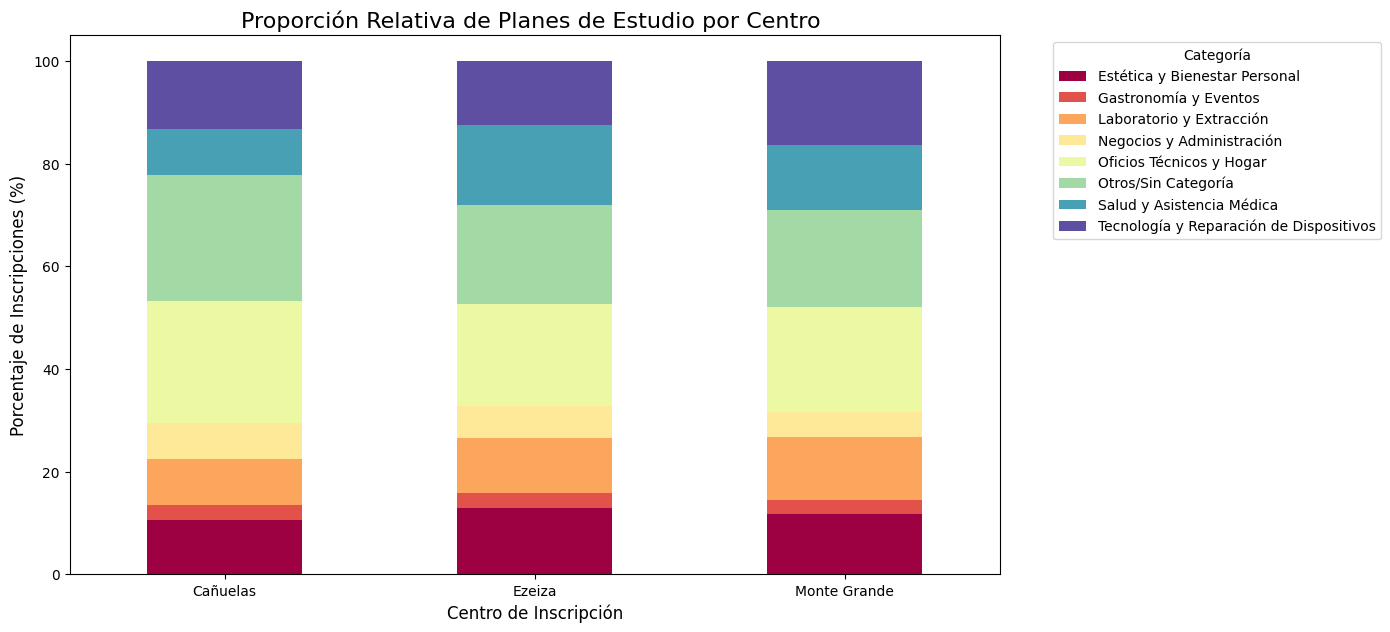

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


plt.figure(figsize=(12, 7))

ax = percentage_table.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    rot=0,
    ax=plt.gca(),
    cmap='Spectral'
)

plt.title('Proporción Relativa de Planes de Estudio por Centro ', fontsize=16)
plt.xlabel('Centro de Inscripción', fontsize=12)
plt.ylabel('Porcentaje de Inscripciones (%)', fontsize=12)

ax.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Tras el análisis de la distribución de las inscripciones, se concluye que la hipótesis planteada sobre una fuerte especialización de los centros no se verifica en los datos. El test cuantitativo que postulaba que la categoría más popular concentraría más del 40\% del total de inscripciones de al menos un centro fue refutado, ya que la máxima concentración observada fue mucho menor. Esto demuestra que no existe una relacion significativa entre la Locación del Centro de inscripción y el Plan de Estudio elegido.

Hipotesis 2: Se plantea que la edad del inscripto ejerce una influencia significativa en la elección del curso. La mediana de edad de los inscriptos en categorías con un fuerte componente tecnológico y empresarial será notablemente más baja que la mediana de edad de las categorías centradas en servicios asistenciales y oficios tradicionales, demostrando que la edad es un predictor clave de la categoría elegida

/tmp/ipython-input-2456544998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


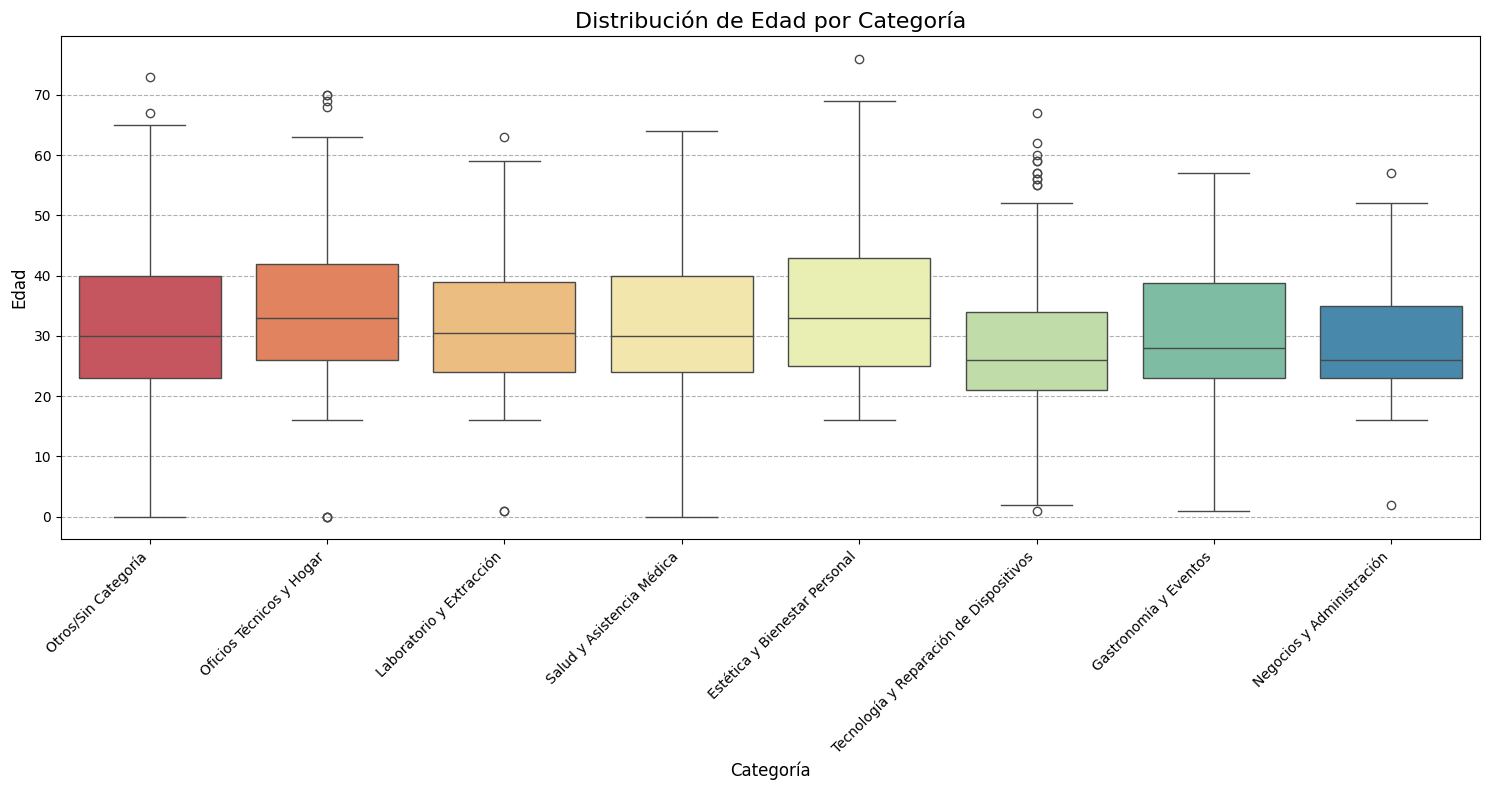

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


plt.figure(figsize=(15, 8))

sns.boxplot(
    x='Categoria',
    y='Edad',
    data=df,
    palette='Spectral'
)

plt.title('Distribución de Edad por Categoría', fontsize=16)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Edad', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

La Hipótesis 2 se confirma, estableciendo una dependencia significativa entre la edad del inscripto y la categoría de curso. La mediana de edad es notablemente más baja en categorías tecnológicas y administrativas, mientras que es más alta en servicios asistenciales y oficios. Por lo tanto, la Edad es un predictor clave para poder anticipar la eleccion

Hipotesis 3: Se postula que la población desempleada y que no ha terminado el colegio secundario, tienden a elegir categorías de curso que ofrecen una capacitación inicial para insertarse laboralmente. Específicamente, la proporción de inscriptos desempleados y sin los estudios secundarios completos  en categorías como 'Salud y Asistencia Médica' y 'Tecnología y Reparación de Dispositivos' será mayor que la proporción de inscriptos desempleados en la categoría con una menor salida laboral directa como 'Estetica y bienestar'

/tmp/ipython-input-1344452005.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


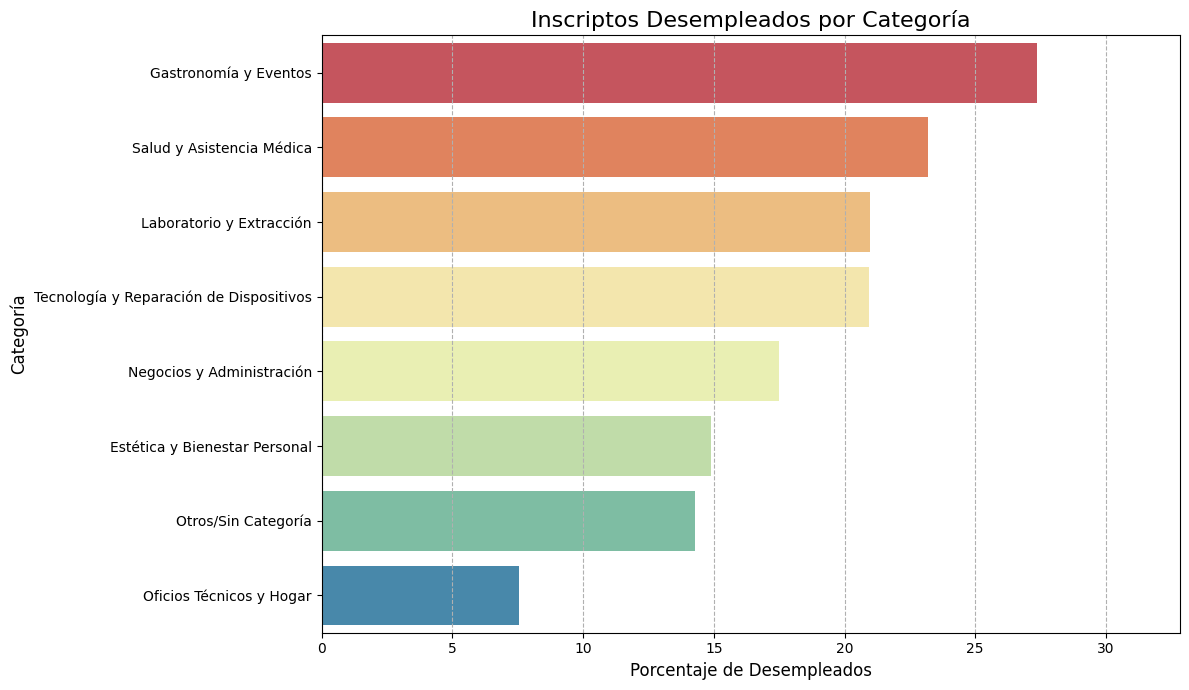

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


plt.figure(figsize=(12, 7))

sns.barplot(
    x='Desempleados (%)',
    y='Categoria',
    data=h5_data_no,
    palette='Spectral'
)

plt.title('Inscriptos Desempleados por Categoría', fontsize=16)
plt.xlabel('Porcentaje de Desempleados', fontsize=12)
plt.ylabel('Categoría', fontsize=12)


plt.xlim(0, h5_data_no['Desempleados (%)'].max() * 1.2)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3561636525.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


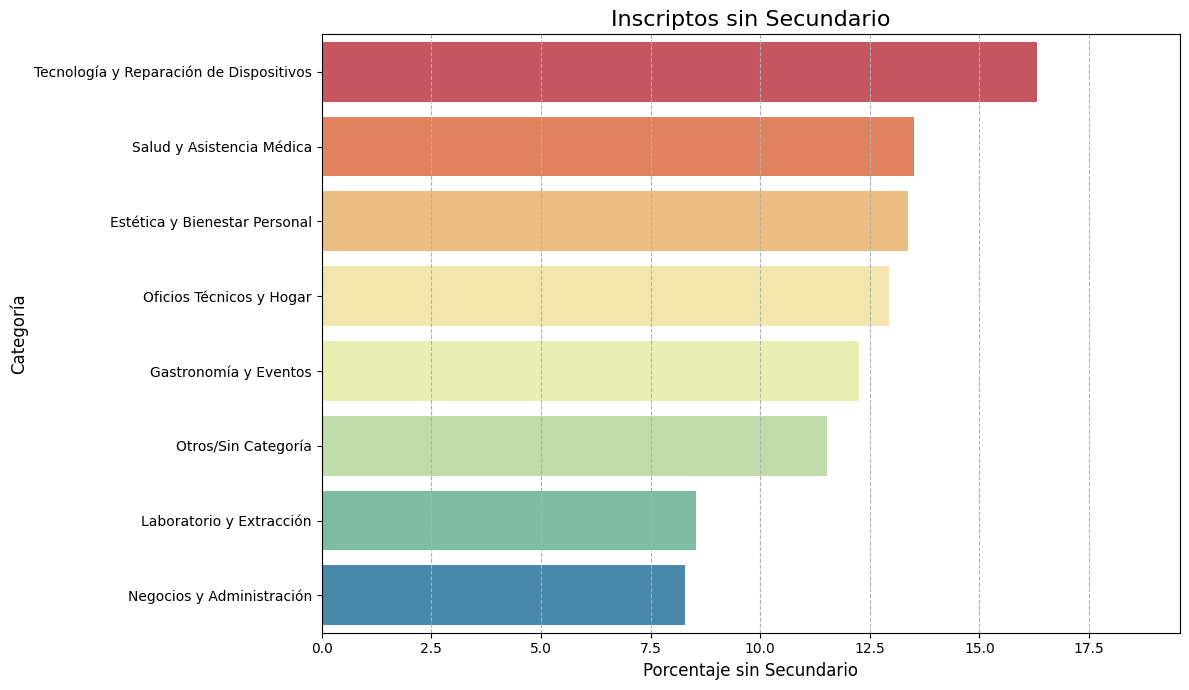

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


plt.figure(figsize=(12, 7))

sns.barplot(
    x='Sin Secundario (%)',
    y='Categoria',
    data=h6_data_no,
    palette='Spectral'
)

plt.title('Inscriptos sin Secundario', fontsize=16)
plt.xlabel('Porcentaje sin Secundario', fontsize=12)
plt.ylabel('Categoría', fontsize=12)


plt.xlim(0, h6_data_no['Sin Secundario (%)'].max() * 1.2)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

La hipótesis se confirma ya que los datos evidencian una concentración consistente de la población vulnerable en las categorías de capacitación vocacional directa.Las categorías objetivo, 'Salud y Asistencia Médica' y 'Tecnología y Reparación de Dispositivos', muestran porcentajes de inscriptos desempleados y sin el secundario completo que son visiblemente mayores o están al mismo nivel de concentración que la categoría base 'Estética y Bienestar Personal'